In [1]:
!pip install -q torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 97.8 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 73.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 45.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 29.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 2.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 84.6 MB/s eta 0:00:00:00:0100:01


In [2]:
import os
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import cv2 as cv
import PIL
from PIL import Image

import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader, random_split, TensorDataset
from torch import optim
from torch.nn import functional as F
import torch.optim.lr_scheduler as lr_scheduler

import torchvision
import torchvision.transforms as T
import torchvision.models as models

import tqdm
import torchmetrics as tm

import warnings
warnings.filterwarnings('ignore')

In [3]:
!python --version

Python 3.11.13


In [4]:
for lib in [np, pd, sns, sklearn, torch, tqdm, tm, torchvision, cv, PIL]:
  print(lib.__name__, '-->', lib.__version__)

numpy --> 1.26.4
pandas --> 2.2.3
seaborn --> 0.12.2
sklearn --> 1.2.2
torch --> 2.6.0+cu124
tqdm --> 4.67.1
torchmetrics --> 1.7.3
torchvision --> 0.21.0+cu124
cv2 --> 4.11.0
PIL --> 11.2.1


In [5]:
class AverageMeter(object):
    """Computes and stores the average and current value"""
    def __init__(self):
        self.reset()

    def reset(self):
        self.val = 0
        self.avg = 0
        self.sum = 0
        self.count = 0

    def update(self, val, n=1):
        self.val = val
        self.sum += val * n
        self.count += n
        self.avg = self.sum / self.count

In [6]:
def num_trainable_params(model):
  nums = sum(p.numel() for p in model.parameters() if p.requires_grad)/1e6
  return nums

In [7]:
def create_csv(path, save_path):
    folders_name = [folder for folder in os.listdir(path) if os.path.isdir(os.path.join(path, folder))]
    folders_path = [f'{path}/{folder}' for folder in folders_name]

    dataset = []
    for i, folder in enumerate(folders_path):
        for image in os.listdir(folder):
            img = []
            image_path = image
            label = folders_name[i]

            img.append(image_path)
            img.append(label)
            dataset.append(img)

    data = pd.DataFrame(dataset)
    data.columns = ['image_name', 'label']

    data.to_csv(save_path, index=False)

In [8]:
create_csv('/kaggle/input/face-expression-recognition-dataset/images/train', '/kaggle/working/train_data.csv')
create_csv('/kaggle/input/face-expression-recognition-dataset/images/validation', '/kaggle/working/valid_data.csv')

In [9]:
train_set = pd.read_csv('/kaggle/working/train_data.csv')
valid_set = pd.read_csv('/kaggle/working/valid_data.csv')

In [10]:
train_set.shape, valid_set.shape

((28821, 2), (7066, 2))

In [11]:
train_set.head()

,image_name,label
0,30778.jpg,surprise
1,22706.jpg,surprise
2,20513.jpg,surprise
3,27582.jpg,surprise
4,33678.jpg,surprise


In [12]:
valid_set.head()

,image_name,label
0,13288.jpg,surprise
1,24201.jpg,surprise
2,26556.jpg,surprise
3,26076.jpg,surprise
4,27577.jpg,surprise


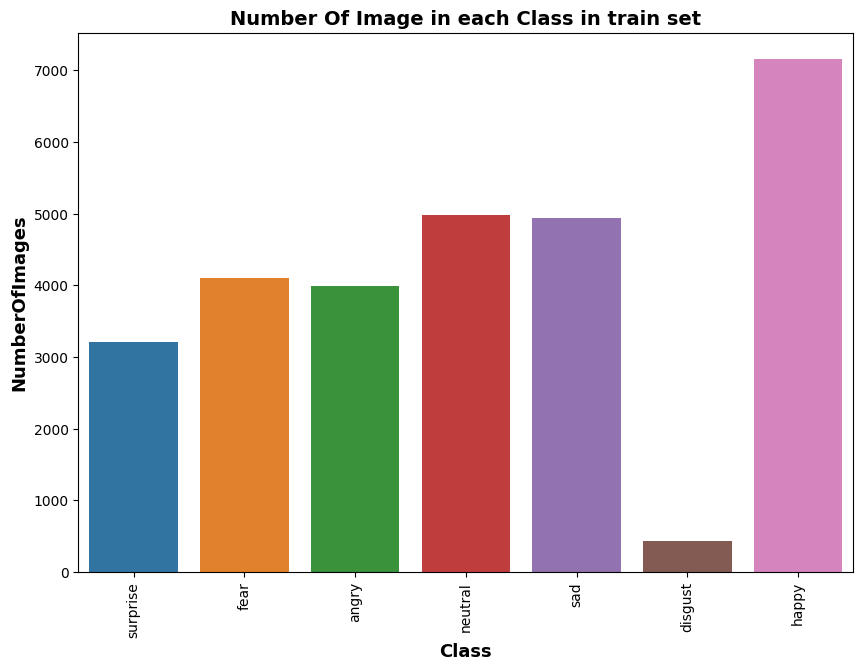

In [13]:
plt.figure(figsize=(10, 7))
sns.countplot(x=train_set['label'])
plt.title(f'Number Of Image in each Class in train set', fontsize=14, fontweight='bold')
plt.xlabel('Class', fontsize=13, fontweight='bold')
plt.ylabel('NumberOfImages', fontsize=13, fontweight='bold')
plt.xticks(rotation=90)
plt.show()

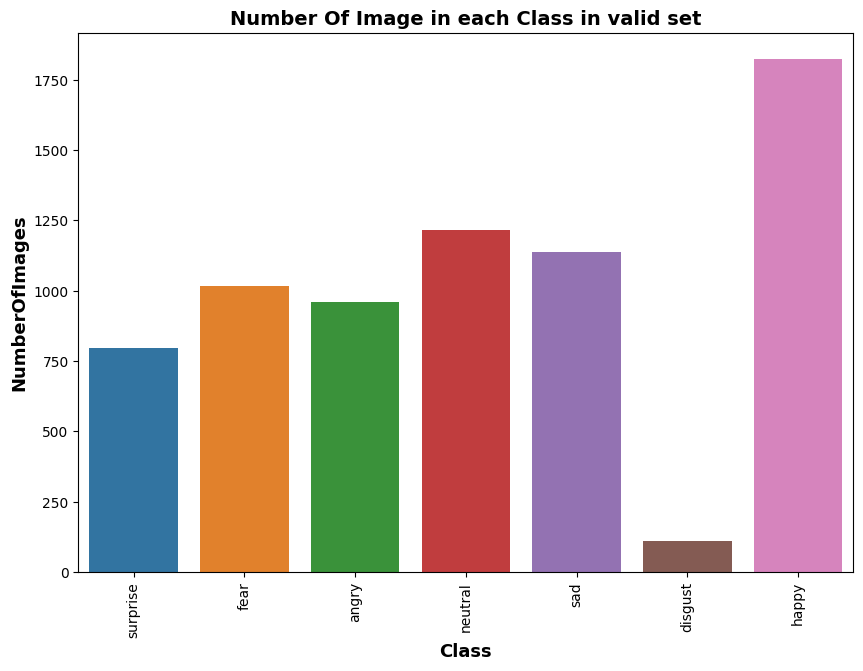

In [14]:
plt.figure(figsize=(10, 7))
sns.countplot(x=valid_set['label'])
plt.title(f'Number Of Image in each Class in valid set', fontsize=14, fontweight='bold')
plt.xlabel('Class', fontsize=13, fontweight='bold')
plt.ylabel('NumberOfImages', fontsize=13, fontweight='bold')
plt.xticks(rotation=90)
plt.show()

In [15]:
df_valid, df_test = train_test_split(valid_set, test_size=0.5, random_state=42, stratify=valid_set.label)

train_set = train_set.sample(frac=1, random_state=42).reset_index(drop=True)
df_valid  = df_valid.sample(frac=1, random_state=42).reset_index(drop=True)
df_test   = df_test.sample(frac=1, random_state=42).reset_index(drop=True)

print(f'Train: {train_set.shape}')
print(f'Valid: {df_valid.shape}')
print(f'Test: {df_test.shape}')

Train: (28821, 2)
Valid: (3533, 2)
Test: (3533, 2)


In [16]:
train_set.to_csv('/kaggle/working/train_set.csv', index=False)
df_valid.to_csv('/kaggle/working/valid_set.csv', index=False)
df_test.to_csv('/kaggle/working/test_set.csv', index=False)

print('All CSV files created successfully.')

All CSV files created successfully.


In [17]:
train_transform = T.Compose([T.Resize((224, 224)),
                             T.RandomHorizontalFlip(),
                             T.RandomRotation(10),
                             T.ToTensor(),
                             T.Normalize(mean=[0.485, 0.456, 0.406],
                                         std=[0.229, 0.224, 0.225])])

valid_transform = T.Compose([T.Resize((224, 224)),
                             T.ToTensor(),
                             T.Normalize(mean=[0.485, 0.456, 0.406],
                                         std=[0.229, 0.224, 0.225])])

In [18]:
class FaceExpressionDataset(Dataset):
  def __init__(self, root_dir, csv_file, transform=None):
    self.root_dir = root_dir
    self.transform = transform
    self.data = pd.read_csv(csv_file)

    category_map = {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3,
                    'neutral': 4, 'sad': 5, 'surprise': 6}

    self.images_list = [f'{root_dir}/{label}/{image}' for label, image in zip(self.data['label'], self.data['image_name'])]
    self.labels = torch.LongTensor(self.data['label'].map(category_map).values).squeeze()

  def __len__(self):
    return len(self.data)

  def __getitem__(self, idx):
    image_path = self.images_list[idx]
    img = Image.open(image_path).convert('RGB')
    img = self.transform(img)
    label = self.labels[idx].item()

    return img, label

In [19]:
train_dataset = FaceExpressionDataset(root_dir='/kaggle/input/face-expression-recognition-dataset/images/train',
                           csv_file='/kaggle/working/train_set.csv',
                           transform=train_transform)

valid_dataset = FaceExpressionDataset(root_dir='/kaggle/input/face-expression-recognition-dataset/images/validation',
                           csv_file='/kaggle/working/valid_set.csv',
                           transform=valid_transform)

test_dataset = FaceExpressionDataset(root_dir='/kaggle/input/face-expression-recognition-dataset/images/validation',
                           csv_file='/kaggle/working/test_set.csv',
                           transform=valid_transform)

In [20]:
category_map = {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3,
                'neutral': 4, 'sad': 5, 'surprise': 6}

def get_keys_by_value(dictionary, value):
    for key, val in dictionary.items():
        if val == value:
            return key

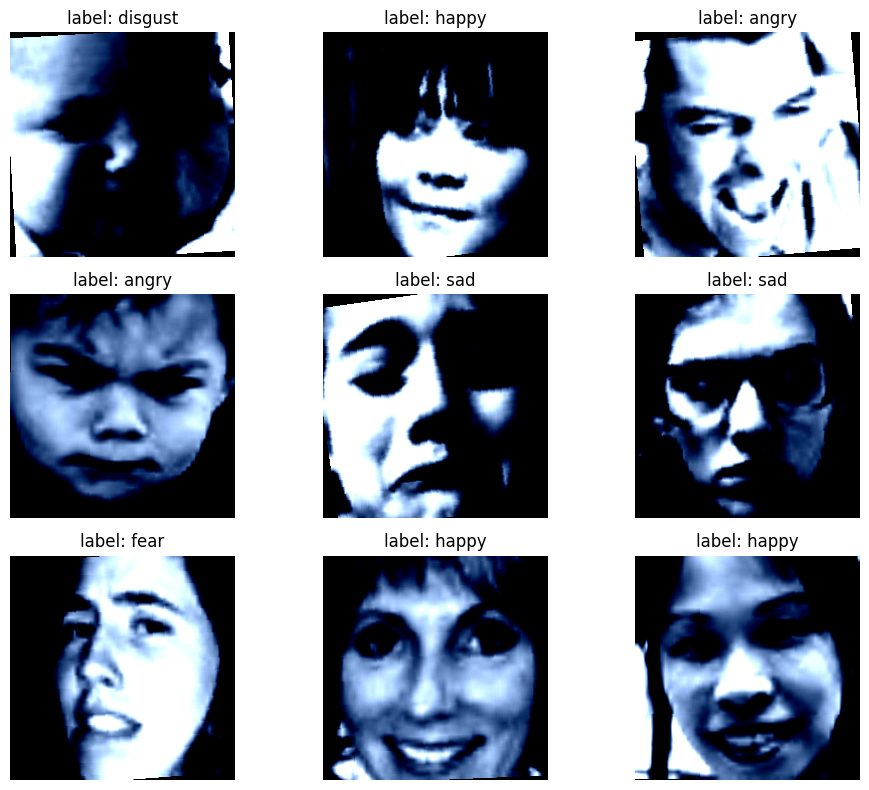

In [21]:
plt.figure(figsize=(10, 8))
for i in range(9):
  image, label = train_dataset[i]


  plt.subplot(3, 3, i+1)
  plt.imshow(image.permute(1, 2, 0))
  plt.title(f"label: {get_keys_by_value(category_map, label)}")
  plt.axis('off')

plt.tight_layout()
plt.show()

In [22]:
def collate(batch):
  imgs = torch.FloatTensor(np.array([b[0].cpu().detach().numpy() for b in batch]))
  labels = torch.LongTensor(np.array([b[1] for b in batch]))

  return imgs, labels

In [23]:
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, collate_fn=collate)
valid_loader = DataLoader(valid_dataset, batch_size=128, shuffle=False, collate_fn=collate)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False, collate_fn=collate)

In [24]:
img, label = next(iter(train_loader))
img.shape, label

(torch.Size([128, 3, 224, 224]),
 tensor([2, 3, 3, 6, 0, 4, 3, 5, 3, 6, 2, 5, 0, 2, 2, 3, 0, 4, 6, 2, 5, 5, 6, 4,
         0, 5, 0, 2, 4, 4, 0, 5, 3, 3, 3, 2, 3, 3, 3, 3, 2, 0, 3, 5, 6, 5, 5, 3,
         3, 3, 5, 3, 4, 6, 4, 2, 4, 2, 2, 3, 4, 3, 0, 5, 0, 3, 5, 3, 5, 0, 3, 4,
         6, 5, 3, 3, 5, 2, 3, 5, 5, 5, 2, 3, 3, 5, 2, 0, 4, 5, 3, 5, 4, 3, 0, 0,
         4, 2, 6, 5, 0, 5, 0, 5, 5, 5, 3, 5, 0, 2, 6, 0, 4, 5, 0, 2, 6, 6, 4, 3,
         2, 5, 2, 0, 6, 6, 5, 4]))

In [25]:
class FaceExpressionModel(nn.Module):

    def __init__(self):
        super().__init__()
        self.model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        self.model.fc = nn.Linear(in_features=2048, out_features=7)
        # nn.init.kaiming_uniform_(self.model.fc.weight, nonlinearity="relu")
        # nn.init.zeros_(self.model.fc.bias)
        
    def forward(self, x):
        y = self.model(x)
        return y

In [ ]:
model = FaceExpressionModel()
model

In [27]:
num_trainable_params(model)

23.522375

In [27]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [28]:
def train_one_epoch(model, train_loader, loss_fn, optimizer, metric1, metric2, epoch=None):
  model.train()
  loss_train = AverageMeter()
  metric1.reset()
  metric2.reset()

  with tqdm.tqdm(train_loader, unit='batch') as tepoch:
    for inputs, targets in tepoch:
      if epoch is not None:
        tepoch.set_description(f'Epoch {epoch}')

      inputs = inputs.to(device)
      targets = targets.to(device)

      outputs = model(inputs)
      loss = loss_fn(outputs, targets)

      loss.backward()

      optimizer.step()
      optimizer.zero_grad()

      loss_train.update(loss.item(), n=len(targets))
      metric1.update(outputs, targets)
      metric2.update(outputs, targets)

      tepoch.set_postfix(loss=loss_train.avg, Accuracy=metric1.compute().item(), F1Score=metric2.compute().item())

  return model, loss_train.avg, metric1.compute().item(), metric2.compute().item()

In [29]:
def evaluate(model, test_loader, loss_fn, metric1, metric2):
  model.eval()
  loss_eval = AverageMeter()
  metric1.reset()
  metric2.reset()

  with torch.inference_mode():
    for inputs, targets in test_loader:
      inputs = inputs.to(device)
      targets = targets.to(device)

      outputs = model(inputs)

      loss = loss_fn(outputs, targets)
      loss_eval.update(loss.item(), n=len(targets))

      metric1(outputs, targets)
      metric2(outputs, targets)

  return loss_eval.avg, metric1.compute().item(), metric2.compute().item()

In [50]:
model = FaceExpressionModel().to(device)

In [51]:
num_trainable_params(model)

23.522375

In [52]:
category_map = {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3,
                'neutral': 4, 'sad': 5, 'surprise': 6}

counts = []
for key in category_map:
    counts.append(train_set['label'].value_counts()[key])

class_counts = torch.tensor(counts, dtype=torch.float)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * len(class_counts)

class_weights = class_weights.to(device)
print(class_weights)

In [55]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

loss_fn = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.1, patience=3)

metric1 = tm.Accuracy(task='multiclass', num_classes=7).to(device)
metric2 = tm.F1Score(task='multiclass', num_classes=7).to(device)

In [56]:
loss_train_hist = []
loss_valid_hist = []

metric1_train_hist = []
metric1_valid_hist = []

metric2_train_hist = []
metric2_valid_hist = []

best_acc_valid = -torch.inf
epoch_counter = 0

In [57]:
num_epochs = 25

for epoch in range(num_epochs):
  # Train
  model, loss_train, metric1_train, metric2_train = train_one_epoch(model,
                                                                    train_loader,
                                                                    loss_fn,
                                                                    optimizer,
                                                                    metric1,
                                                                    metric2,
                                                                    epoch)
  # Validation
  loss_valid, metric1_valid, metric2_valid = evaluate(model,
                                                      valid_loader,
                                                      loss_fn,
                                                      metric1,
                                                      metric2)

  # scheduler.step(metric1_valid)

  loss_train_hist.append(loss_train)
  loss_valid_hist.append(loss_valid)

  metric1_train_hist.append(metric1_train)
  metric1_valid_hist.append(metric1_valid)

  metric2_train_hist.append(metric2_train)
  metric2_valid_hist.append(metric2_valid)

  print(f'Valid: Loss = {loss_valid:.4}, Accuracy = {metric1_valid:.4}, F1Score = {metric2_valid:.4}')

  if metric1_valid > best_acc_valid:
    torch.save(model, f'/kaggle/working/model_resnet50.pt')
    best_acc_valid = metric1_valid
    print('Model Saved!')
  print()

  epoch_counter += 1

Epoch 0: 100%|██████████| 226/226 [03:51<00:00,  1.03s/batch, Accuracy=0.412, F1Score=0.412, loss=1.52]


Valid: Loss = 1.194, Accuracy = 0.5358, F1Score = 0.5358
Model Saved!



Epoch 1: 100%|██████████| 226/226 [03:43<00:00,  1.01batch/s, Accuracy=0.581, F1Score=0.581, loss=1.09]


Valid: Loss = 1.051, Accuracy = 0.6001, F1Score = 0.6001
Model Saved!



Epoch 2: 100%|██████████| 226/226 [03:38<00:00,  1.04batch/s, Accuracy=0.643, F1Score=0.643, loss=0.907]


...

Valid: Loss = 1.538, Accuracy = 0.7096, F1Score = 0.7096
Model Saved!



Epoch 23: 100%|██████████| 226/226 [03:38<00:00,  1.04batch/s, Accuracy=0.992, F1Score=0.992, loss=0.0255]


Valid: Loss = 1.559, Accuracy = 0.7045, F1Score = 0.7045



Epoch 24: 100%|██████████| 226/226 [04:03<00:00,  1.08s/batch, Accuracy=0.993, F1Score=0.993, loss=0.0234]


Valid: Loss = 1.561, Accuracy = 0.7093, F1Score = 0.7093



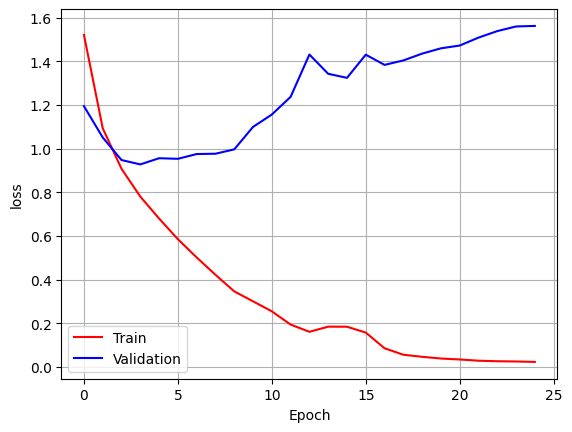

In [58]:
plt.plot(range(epoch_counter), loss_train_hist, 'r-', label='Train')
plt.plot(range(epoch_counter), loss_valid_hist, 'b-', label='Validation')

plt.xlabel('Epoch')
plt.ylabel('loss')
plt.grid(True)
plt.legend()
plt.show()

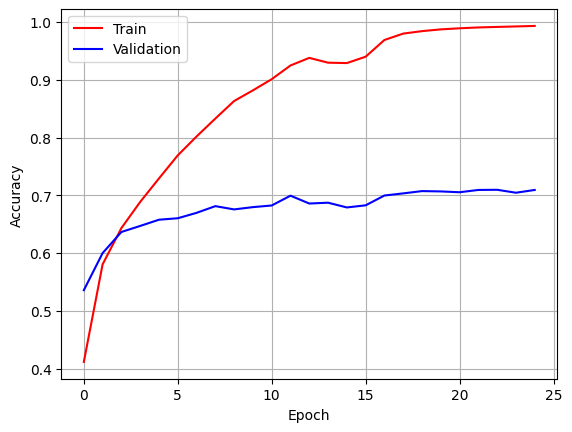

In [59]:
plt.plot(range(epoch_counter), metric1_train_hist, 'r-', label='Train')
plt.plot(range(epoch_counter), metric1_valid_hist, 'b-', label='Validation')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()
plt.show()

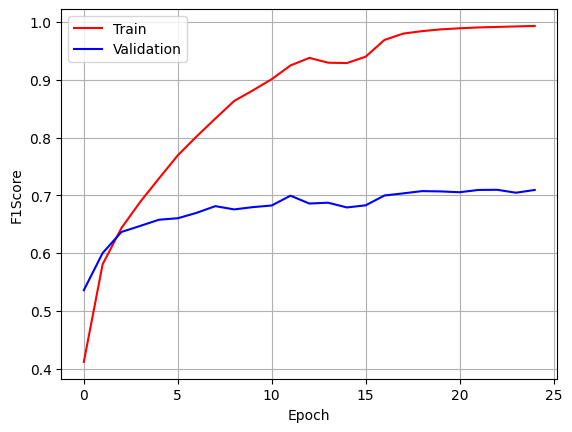

In [60]:
plt.plot(range(epoch_counter), metric1_train_hist, 'r-', label='Train')
plt.plot(range(epoch_counter), metric1_valid_hist, 'b-', label='Validation')

plt.xlabel('Epoch')
plt.ylabel('F1Score')
plt.grid(True)
plt.legend()
plt.show()

In [62]:
best_model = torch.load('/kaggle/working/model_resnet50.pt', weights_only=False)

In [63]:
loss_train, metric1_train, metric2_train = evaluate(best_model, train_loader, loss_fn, metric1, metric2)
loss_valid, metric1_valid, metric2_valid = evaluate(best_model, valid_loader, loss_fn, metric1, metric2)
loss_test, metric1_test, metric2_test = evaluate(best_model, test_loader, loss_fn, metric1, metric2)

In [64]:
print(f'Train : CrossEntropyLoss = {loss_train:.2} , Accuracy = {metric1_train:.2} , F1Score = {metric2_train:.2}')
print(f'Valid : CrossEntropyLoss = {loss_valid:.2} , Accuracy = {metric1_valid:.2} , F1Score = {metric2_valid:.2}')
print(f'Test : CrossEntropyLoss = {loss_test:.2} , Accuracy = {metric1_test:.2} , F1Score = {metric2_test:.2}')

Train : CrossEntropyLoss = 0.018 , Accuracy = 0.99 , F1Score = 0.99
Valid : CrossEntropyLoss = 1.5 , Accuracy = 0.71 , F1Score = 0.71
Test : CrossEntropyLoss = 1.7 , Accuracy = 0.69 , F1Score = 0.69


In [ ]:
final_df = {
    'Phase': ['Train', 'Validation', 'Test'],
    'CrossEntropyLoss': [round(loss_train, 2), round(loss_valid, 2), round(loss_test, 2)],
    'Accuracy': [round(metric1_train, 2), round(metric1_valid, 2), round(metric1_test, 2)],
    'F1Score': [round(metric2_train, 2), round(metric2_valid, 2), round(metric2_test, 2)],
}

df = pd.DataFrame(final_df)
df.to_csv('/kaggle/working/results.csv', index=False)

In [ ]:
df